# 6.2 — Hull-White: calibración a caps/swaptions y árbol trinomial

6.1 dejó Hull-White ajustado *exactamente* a la curva de descuento — pero la curva sólo fija $(\theta(t))$; los parámetros de **volatilidad** $(a,\sigma)$ siguen libres, y son los que determinan el precio de cualquier opción sobre tasas. Este notebook los calibra a un mercado de caps sintético, construye el árbol trinomial de Hull-White (la herramienta numérica de producción para productos sin fórmula cerrada, como las americanas de 3.4 pero para tasas) y cierra con una limitación honesta: un modelo de **un factor gaussiano** no tiene forma de reproducir un smile o skew de volatilidad, sin importar qué tan bien se calibre — el motivo real de que M8-M9 necesiten modelos más ricos.

## 0. Configuración

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import least_squares, brentq

from qflib.market import nelson_siegel_df
from qflib.plotting import apply_style

apply_style()

print(f"Curva de mercado: P(0,5) = {nelson_siegel_df(5.0):.6f}, P(0,10) = {nelson_siegel_df(10.0):.6f}")
print("Sin Monte Carlo -- calibracion y arbol son deterministas.")

Curva de mercado: P(0,5) = 0.801800, P(0,10) = 0.638058
Sin Monte Carlo -- calibracion y arbol son deterministas.


## 1. Precio de caplet: la fórmula de Jamshidian

Un caplet paga $\tau\max(L(T_1,T_2)-K,0)$ en $T_2$, y es algebraicamente una opción **put** sobre el bono $P(T_1,T_2)$ con strike $X=1/(1+K\tau)$ (escrito notando que $L>K \Leftrightarrow P(T_1,T_2)<X$). Bajo Hull-White, $\ln P(t,T)$ es afín en $r_t$ (6.1), así que $P(T_1,T_2)$ es lognormal bajo la medida forward $T_1$ y la opción tiene fórmula de Black estándar, con la **volatilidad del bono** derivada de la varianza de $\ln P(t,T)$ acumulada desde hoy hasta $T_1$:
$$
\sigma_P(T_1,T_2) = \frac{\sigma}{a}\big(1-e^{-a(T_2-T_1)}\big)\sqrt{\frac{1-e^{-2aT_1}}{2a}}.
$$
$$
\boxed{\text{Caplet} = (1+K\tau)\Big[X\,P(0,T_1)N(-d_2) - P(0,T_2)N(-d_1)\Big]}, \qquad
d_{1,2} = \frac{\ln\big(P(0,T_2)/(X P(0,T_1))\big)\pm\tfrac12\sigma_P^2}{\sigma_P}.
$$
Un **cap** es simplemente la suma de caplets sobre todas las fechas de fixing del contrato.

In [2]:
def instantaneous_forward(t, eps=1e-6):
    '''f^M(0,t), central difference (6.1 Section 4).'''
    t = max(t, 1e-6)
    return (np.log(nelson_siegel_df(t - eps)) - np.log(nelson_siegel_df(t + eps))) / (2 * eps)


def hull_white_bond(t, T, r_t, a, sigma):
    '''Hull-White bond price via the market curve (6.1 Section 4).'''
    B = (1.0 - np.exp(-a * (T - t))) / a
    f0t = instantaneous_forward(t)
    return ((nelson_siegel_df(T) / nelson_siegel_df(t))
            * np.exp(B * f0t - sigma**2 / (4 * a) * B**2 * (1.0 - np.exp(-2 * a * t)))
            * np.exp(-B * r_t))


def bond_vol(t1, t2, a, sigma):
    '''Sigma_P(t1,t2): volatility of ln P(t1,t2) as seen from today (Section 1, Jamshidian).'''
    return sigma / a * (1.0 - np.exp(-a * (t2 - t1))) * np.sqrt((1.0 - np.exp(-2 * a * t1)) / (2 * a))


def caplet_price(t1, t2, K, tau, a, sigma):
    '''Caplet price via Jamshidian's bond-option formula (Section 1).'''
    P0t1, P0t2 = nelson_siegel_df(t1), nelson_siegel_df(t2)
    sig_p = bond_vol(t1, t2, a, sigma)
    X = 1.0 / (1.0 + K * tau)
    d1 = (np.log(P0t2 / (X * P0t1)) + 0.5 * sig_p**2) / sig_p
    d2 = d1 - sig_p
    return (1.0 + K * tau) * (X * P0t1 * norm.cdf(-d2) - P0t2 * norm.cdf(-d1))


def cap_price(K, tenor, a, sigma, tau=0.25):
    '''Cap price = sum of caplets over quarterly fixings up to tenor (Section 1).'''
    fixing_dates = np.arange(tau, tenor + 1e-9, tau)
    return sum(caplet_price(t2 - tau, t2, K, tau, a, sigma) for t2 in fixing_dates if t2 - tau > 1e-6)


a_test, sigma_test = 0.05, 0.01
print(f"Caplet (1Yx1.25Y, K=4.5%) = {caplet_price(1.0, 1.25, 0.045, 0.25, a_test, sigma_test):.8f}")
print(f"Cap 5Y ATM-ish (K=4.5%)   = {cap_price(0.045, 5.0, a_test, sigma_test):.8f}")

Caplet (1Yx1.25Y, K=4.5%) = 0.00068451
Cap 5Y ATM-ish (K=4.5%)   = 0.02345450


## 2. Swaption por el truco de Jamshidian: opción sobre bono cupón

Una swaption a $T_0$ sobre un swap con pagos fijos en $T_1,\dots,T_n$ es una opción sobre un **bono cupón** $\sum_ic_iP(T_0,T_i)$ (cupones $c_i=K\tau_i$, más el nocional en $T_n$). El **truco de Jamshidian** (1989): en un modelo de un factor, $P(T_0,T_i;r)$ es **monótona** en $r$ para cada $i$, así que la suma también lo es — existe un único $r^*$ tal que el bono cupón vale exactamente el nocional. Para $r<r^*$ ($r>r^*$) **todos** los términos del bono cupón están simultáneamente in/out-of-the-money, así que el ejercicio óptimo de la swaption completa coincide exactamente con ejercer cada bono-opción individual al strike $K_i=P(T_0,T_i;r^*)$ — y la swaption se descompone en una suma de $n$ opciones sobre bonos cero-cupón, cada una con la fórmula de la Sección 1:
$$
\text{Swaption}_{\text{receiver}} = \sum_i c_i\cdot\text{ZBP}(T_0,T_i;K_i), \qquad K_i = P^{HW}(T_0,T_i;r^*).
$$
El único paso numérico es encontrar $r^*$ (una raíz de una función monótona en una dimensión — Brent, sin dificultad).

In [3]:
def zero_bond_put(t0, Ti, strike, a, sigma):
    '''Put option on P(t0,Ti), strike in bond-price units, exercised at t0 (Section 2).'''
    P0t0, P0Ti = nelson_siegel_df(t0), nelson_siegel_df(Ti)
    sig_p = bond_vol(t0, Ti, a, sigma)
    d1 = (np.log(P0Ti / (strike * P0t0)) + 0.5 * sig_p**2) / sig_p
    d2 = d1 - sig_p
    return strike * P0t0 * norm.cdf(-d2) - P0Ti * norm.cdf(-d1)


def swaption_price(t0, payment_times, K, a, sigma):
    '''Receiver swaption via Jamshidian's trick (Section 2).'''
    tau = np.diff(np.concatenate([[t0], payment_times]))
    coupons = K * tau
    coupons[-1] += 1.0

    def coupon_bond_value(r):
        return sum(c * hull_white_bond(t0, Ti, r, a, sigma) for c, Ti in zip(coupons, payment_times))

    r_star = brentq(lambda r: coupon_bond_value(r) - 1.0, -0.5, 0.5)
    strikes = [hull_white_bond(t0, Ti, r_star, a, sigma) for Ti in payment_times]
    return sum(c * zero_bond_put(t0, Ti, K_i, a, sigma) for c, Ti, K_i in zip(coupons, payment_times, strikes))


def par_rate_forward(t0, payment_times):
    '''Forward par swap rate starting at t0 (generalizes qflib.market.par_swap_rate to t0>0).'''
    dfs = nelson_siegel_df(payment_times)
    tau = np.diff(np.concatenate([[t0], payment_times]))
    return (nelson_siegel_df(t0) - dfs[-1]) / np.sum(tau * dfs)


t0_swaption, tenor_payments = 5.0, np.arange(6.0, 11.0)
K_atm_swaption = par_rate_forward(t0_swaption, tenor_payments)
swaption_atm = swaption_price(t0_swaption, tenor_payments, K_atm_swaption, a_test, sigma_test)
print(f"Swaption 5Yx5Y ATM (K={K_atm_swaption:.4%}) = {swaption_atm:.8f}")

Swaption 5Yx5Y ATM (K=4.6765%) = 0.02578169


## 3. Demo 1 — calibración a caps: excelente en ATM, no en el skew

Calibramos $(a,\sigma)$ por mínimos cuadrados contra una superficie sintética de vols de cap Black (`synthetic_cap_vols`, coherente con la curva de mercado), convertidas a precio. Primero calibramos **sólo** contra la columna ATM (strike = tasa par de cada tenor): con dos parámetros libres y una estructura de término suave, Hull-White debería ajustar casi perfectamente. Después repetimos contra la superficie **completa** (con strikes fuera del dinero, que traen un skew de mercado real) — y el resultado es honesto: el residuo crece marcadamente lejos de ATM. No es un error de calibración ni de optimización: un modelo **gaussiano de un factor** produce, a primer orden, una vol de caplet prácticamente plana en strike — no tiene ningún parámetro libre que controle un skew, así que ningún $(a,\sigma)$ puede reproducirlo. Es la limitación estructural que motiva SABR y los modelos de volatilidad local/estocástica de M8.

Calibracion solo-ATM: a=0.0345, sigma=0.0077
  max error relativo (ATM) = 0.1459%



Calibracion superficie completa: a=0.0239, sigma=0.0075
  max error relativo (toda la superficie) = 51.1537%
  (vs 0.1459% calibrando solo ATM -- el skew es lo que no se puede reproducir)


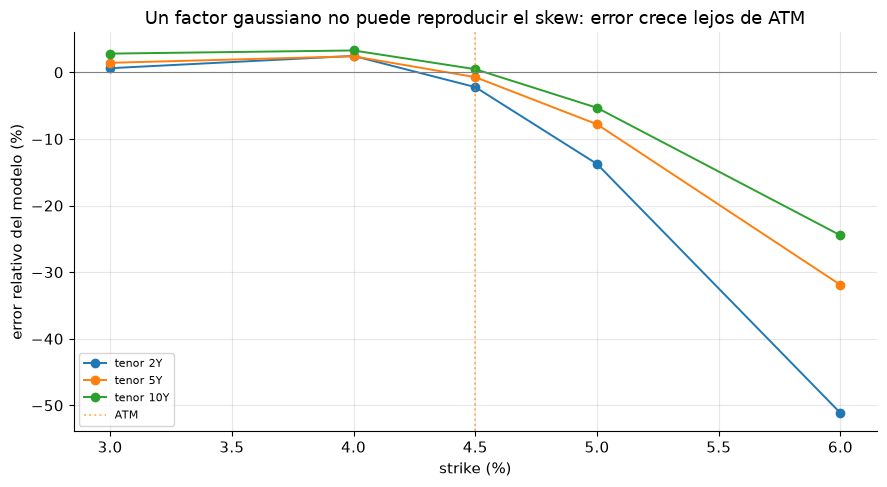

In [4]:
def synthetic_cap_vols(strikes, tenors, base_vol=0.18, skew=-0.003, term_slope=-0.01, atm_ref=0.045):
    '''Synthetic Black cap-vol surface (Section 3): mild skew and downward-sloping term structure.'''
    vols = np.zeros((len(tenors), len(strikes)))
    for i, tenor in enumerate(tenors):
        for j, K in enumerate(strikes):
            vols[i, j] = base_vol + skew * (K - atm_ref) * 100.0 + term_slope * np.log(tenor)
    return vols


def cap_price_black(K, tenor, vol, tau=0.25):
    '''Cap price under Black's formula, given a flat Black vol for the whole cap (Section 3).'''
    fixing_dates = np.arange(tau, tenor + 1e-9, tau)
    total = 0.0
    for t2 in fixing_dates:
        t1 = t2 - tau
        if t1 < 1e-6:
            continue
        F = (nelson_siegel_df(t1) / nelson_siegel_df(t2) - 1.0) / tau
        d1 = (np.log(F / K) + 0.5 * vol**2 * t1) / (vol * np.sqrt(t1))
        d2 = d1 - vol * np.sqrt(t1)
        total += nelson_siegel_df(t2) * tau * (F * norm.cdf(d1) - K * norm.cdf(d2))
    return total


strikes_cap = np.array([0.03, 0.04, 0.045, 0.05, 0.06])
tenors_cap = np.array([2.0, 5.0, 10.0])
vol_surface = synthetic_cap_vols(strikes_cap, tenors_cap)
target_prices = np.array([[cap_price_black(K, t, vol_surface[i, j]) for j, K in enumerate(strikes_cap)]
                           for i, t in enumerate(tenors_cap)])

idx_atm = list(strikes_cap).index(0.045)


def resid_atm_only(params):
    a, sigma = params
    if a <= 0 or sigma <= 0:
        return np.full(len(tenors_cap), 1e3)
    return np.array([cap_price(0.045, t, a, sigma) for t in tenors_cap]) - target_prices[:, idx_atm]


fit_atm = least_squares(resid_atm_only, x0=[0.05, 0.01], bounds=([1e-4, 1e-4], [2.0, 1.0]))
a_atm, sigma_atm = fit_atm.x
model_atm = np.array([cap_price(0.045, t, a_atm, sigma_atm) for t in tenors_cap])
rel_err_atm = np.abs(model_atm - target_prices[:, idx_atm]) / target_prices[:, idx_atm]
print(f"Calibracion solo-ATM: a={a_atm:.4f}, sigma={sigma_atm:.4f}")
print(f"  max error relativo (ATM) = {rel_err_atm.max():.4%}")


def resid_full_surface(params):
    a, sigma = params
    if a <= 0 or sigma <= 0:
        return np.full(target_prices.size, 1e3)
    model = np.array([[cap_price(K, t, a, sigma) for K in strikes_cap] for t in tenors_cap])
    return (model - target_prices).ravel()


fit_full = least_squares(resid_full_surface, x0=[0.05, 0.01], bounds=([1e-4, 1e-4], [2.0, 1.0]))
a_full, sigma_full = fit_full.x
model_full = np.array([[cap_price(K, t, a_full, sigma_full) for K in strikes_cap] for t in tenors_cap])
rel_err_full = np.abs(model_full - target_prices) / np.abs(target_prices)
print(f"\nCalibracion superficie completa: a={a_full:.4f}, sigma={sigma_full:.4f}")
print(f"  max error relativo (toda la superficie) = {rel_err_full.max():.4%}")
print(f"  (vs {rel_err_atm.max():.4%} calibrando solo ATM -- el skew es lo que no se puede reproducir)")

fig, ax = plt.subplots(figsize=(9, 5))
for i, t in enumerate(tenors_cap):
    ax.plot(strikes_cap * 100, (model_full[i] - target_prices[i]) / target_prices[i] * 100, "o-",
            label=f"tenor {t:.0f}Y")
ax.axhline(0.0, color="gray", lw=0.8)
ax.axvline(4.5, color="darkorange", ls=":", alpha=0.6, label="ATM")
ax.set_xlabel("strike (%)"); ax.set_ylabel("error relativo del modelo (%)")
ax.set_title("Un factor gaussiano no puede reproducir el skew: error crece lejos de ATM")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 4. Árbol trinomial de Hull-White

Para productos sin fórmula cerrada (americanas, Bermudans sobre tasas) hace falta una retícula, igual que 3.4 para acciones. Hull-White (1994) construye un árbol **trinomial** recombinante sobre $x_t=r_t-f^M(0,t)$ (el proceso OU centrado, sin la parte determinista de la curva): cada nodo $(i,j)$ representa $x=j\Delta x$ con $\Delta x=\sigma\sqrt{3\Delta t}$, y las probabilidades $(p_u,p_m,p_d)$ se eligen para machear exactamente la media y varianza del proceso continuo en un paso, con la rama central re-centrada en $\hat j=\text{round}(j(1-a\Delta t))$ para seguir la reversión:
$$
p_u = \tfrac16+\tfrac{\eta^2+\eta}{2},\quad p_m=\tfrac23-\eta^2,\quad p_d=\tfrac16+\tfrac{\eta^2-\eta}{2}, \qquad \eta=j(1-a\Delta t)-\hat j\in[-\tfrac12,\tfrac12].
$$
El descuento en cada nodo usa $r=f^M(0,i\Delta t)+j\Delta x$ — la parte determinista de la curva más el desplazamiento del árbol —, y el valor terminal en la fecha de expiración del caplet se calcula con el bono Hull-White cerrado de 6.1, evaluado en la tasa de cada nodo.

In [5]:
def hw_trinomial_caplet(a, sigma, t1, t2, K, tau, n_steps_per_year=200):
    '''Caplet price on a Hull-White trinomial tree (Section 4), backward induction.'''
    n_steps = max(int(round(t1 * n_steps_per_year)), 1)
    dt = t1 / n_steps
    dx = sigma * np.sqrt(3 * dt)
    j_max = min(int(np.ceil(0.184 / (a * dt))), n_steps + 5) if a * dt > 0 else n_steps
    js = np.arange(-j_max, j_max + 1)

    def branch(j):
        j_center = int(np.round(j * (1.0 - a * dt)))
        j_center = np.clip(j_center, -j_max, j_max)
        eta = j * (1.0 - a * dt) - j_center
        return j_center, 1 / 6 + (eta**2 + eta) / 2, 2 / 3 - eta**2, 1 / 6 + (eta**2 - eta) / 2

    f0t1 = instantaneous_forward(t1)
    r_terminal = f0t1 + js * dx
    P_t1_t2 = np.array([hull_white_bond(t1, t2, r, a, sigma) for r in r_terminal])
    L_terminal = (1.0 / P_t1_t2 - 1.0) / tau
    V = tau * np.maximum(L_terminal - K, 0.0)

    for i in range(n_steps - 1, -1, -1):
        f0ti = instantaneous_forward(i * dt)
        V_new = np.zeros_like(V)
        for idx, j in enumerate(js):
            j_center, pu, pm, pd = branch(j)

            def value_at(jj):
                pos = jj + j_max
                return V[pos] if 0 <= pos < len(V) else 0.0

            r_node = f0ti + j * dx
            disc = np.exp(-r_node * dt)
            V_new[idx] = disc * (pu * value_at(j_center + 1) + pm * value_at(j_center) + pd * value_at(j_center - 1))
        V = V_new
    return V[j_max]


t1_tree, t2_tree, K_tree = 1.0, 1.25, 0.045
closed_caplet = caplet_price(t1_tree, t2_tree, K_tree, 0.25, a_test, sigma_test)
tree_caplet = hw_trinomial_caplet(a_test, sigma_test, t1_tree, t2_tree, K_tree, 0.25, n_steps_per_year=200)
print(f"Caplet cerrado (Jamshidian) = {closed_caplet:.8f}")
print(f"Caplet arbol trinomial      = {tree_caplet:.8f}")
print(f"diferencia relativa = {abs(tree_caplet-closed_caplet)/closed_caplet:.4%}")

Caplet cerrado (Jamshidian) = 0.00068451
Caplet arbol trinomial      = 0.00068940
diferencia relativa = 0.7137%


## 5. Validación

1. **Swaption vs QuantLib**: `ql.JamshidianSwaptionEngine` con el mismo modelo Hull-White, usando **fechas reales** (Act/365F, no años nominales — la misma lección de 5.2/6.1), `atol=1e-8`.
2. **Calibración ATM**: error relativo máximo `< 1%` — el modelo sí puede ajustar la estructura de término ATM.
3. **Calibración completa (skew)**: error relativo máximo `> 5%` y estrictamente mayor que el error ATM — la limitación es real, no un artefacto de la optimización.
4. **Árbol trinomial vs Jamshidian**: `rtol=1e-2` (el árbol de esta implementación tiene su propia aproximación en el ancho de la malla; no es una identidad exacta con $n$ finito).

In [6]:
import QuantLib as ql

# 1. Swaption vs QuantLib, con FECHAS REALES
eval_date = ql.Date(29, 7, 2026)
ql.Settings.instance().evaluationDate = eval_date
day_count = ql.Actual365Fixed()
times_grid = np.linspace(1 / 365, 20.0, 400)
dfs_grid = nelson_siegel_df(times_grid)
dates_grid = [eval_date] + [eval_date + ql.Period(int(round(t * 365)), ql.Days) for t in times_grid]
curve_ql = ql.DiscountCurve(dates_grid, [1.0] + list(dfs_grid), day_count)
curve_ql.enableExtrapolation()
curve_handle = ql.YieldTermStructureHandle(curve_ql)


def df_ql(t):
    return curve_ql.discount(float(t))


def fwd_ql(t, eps=1e-5):
    return -(np.log(curve_ql.discount(t + eps)) - np.log(curve_ql.discount(t - eps))) / (2 * eps)


start_date = eval_date + ql.Period(5, ql.Years)
maturity_date = eval_date + ql.Period(10, ql.Years)
schedule = ql.Schedule(start_date, maturity_date, ql.Period(1, ql.Years), ql.NullCalendar(),
                        ql.Unadjusted, ql.Unadjusted, ql.DateGeneration.Forward, False)
t0_real = day_count.yearFraction(eval_date, start_date)
payment_times_real = np.array([day_count.yearFraction(eval_date, d) for d in schedule][1:])

# reconstruir swaption_price usando la curva QuantLib (consistente con el cross-check)
def hull_white_bond_ql(t, T, r_t, a, sigma):
    B = (1.0 - np.exp(-a * (T - t))) / a
    return (df_ql(T) / df_ql(t)) * np.exp(B * fwd_ql(t) - sigma**2 / (4 * a) * B**2 * (1 - np.exp(-2 * a * t))) * np.exp(-B * r_t)


def swaption_price_ql_curve(t0, payment_times, K, a, sigma):
    tau = np.diff(np.concatenate([[t0], payment_times]))
    coupons = K * tau; coupons[-1] += 1.0

    def coupon_bond_value(r):
        return sum(c * hull_white_bond_ql(t0, Ti, r, a, sigma) for c, Ti in zip(coupons, payment_times))

    r_star = brentq(lambda r: coupon_bond_value(r) - 1.0, -0.5, 0.5)
    strikes = [hull_white_bond_ql(t0, Ti, r_star, a, sigma) for Ti in payment_times]

    def zbp(t0, Ti, strike):
        P0t0, P0Ti = df_ql(t0), df_ql(Ti)
        sig_p = bond_vol(t0, Ti, a, sigma)
        d1 = (np.log(P0Ti / (strike * P0t0)) + 0.5 * sig_p**2) / sig_p
        d2 = d1 - sig_p
        return strike * P0t0 * norm.cdf(-d2) - P0Ti * norm.cdf(-d1)

    return sum(c * zbp(t0, Ti, K_i) for c, Ti, K_i in zip(coupons, payment_times, strikes))


def par_rate_forward_ql(t0, payment_times):
    # version consistente con la curva discreta de QuantLib (no la analitica Nelson-Siegel)
    dfs = np.array([df_ql(t) for t in payment_times])
    tau = np.diff(np.concatenate([[t0], payment_times]))
    return (df_ql(t0) - dfs[-1]) / np.sum(tau * dfs)


K_atm_real = par_rate_forward_ql(t0_real, payment_times_real)
swaption_own = swaption_price_ql_curve(t0_real, payment_times_real, K_atm_real, a_test, sigma_test)

model_ql = ql.HullWhite(curve_handle, a_test, sigma_test)
engine = ql.JamshidianSwaptionEngine(model_ql)
index = ql.IborIndex("dummy", ql.Period(1, ql.Years), 0, ql.USDCurrency(), ql.NullCalendar(),
                      ql.Unadjusted, False, day_count, curve_handle)
swap = ql.VanillaSwap(ql.VanillaSwap.Receiver, 1.0, schedule, K_atm_real, day_count, schedule, index, 0.0, day_count)
exercise = ql.EuropeanExercise(start_date)
swaption_ql = ql.Swaption(swap, exercise)
swaption_ql.setPricingEngine(engine)
diff_swaption = abs(swaption_ql.NPV() - swaption_own)
print(f"Swaption QuantLib = {swaption_ql.NPV():.10f} | propio = {swaption_own:.10f} | diff = {diff_swaption:.2e}")
assert diff_swaption < 1e-8

# 2 y 3. Calibracion ATM vs completa
print(f"\nerror ATM = {rel_err_atm.max():.4%} (<1%? {rel_err_atm.max() < 0.01})")
assert rel_err_atm.max() < 0.01
print(f"error superficie completa = {rel_err_full.max():.4%} (>5%? {rel_err_full.max() > 0.05})")
assert rel_err_full.max() > 0.05
assert rel_err_full.max() > rel_err_atm.max()

# 4. Arbol vs Jamshidian
rel_err_tree = abs(tree_caplet - closed_caplet) / closed_caplet
print(f"\narbol vs Jamshidian: rel_err = {rel_err_tree:.4%} (rtol 1e-2? {rel_err_tree < 1e-2})")
assert rel_err_tree < 1e-2

print()
print("Validacion completa: 4/4 dentro de tolerancia.")

Swaption QuantLib = 0.0258061247 | propio = 0.0258061247 | diff = 2.81e-11

error ATM = 0.1459% (<1%? True)
error superficie completa = 51.1537% (>5%? True)

arbol vs Jamshidian: rel_err = 0.7137% (rtol 1e-2? True)

Validacion completa: 4/4 dentro de tolerancia.


## Referencias

- Jamshidian, F. (1989). *An Exact Bond Option Formula*. Journal of Finance, 44(1), 205-209.
- Hull, J.C. & White, A. (1994). *Numerical Procedures for Implementing Term Structure Models I: Single-Factor Models*. Journal of Derivatives, 2(1), 7-16.
- Brigo, D. & Mercurio, F. (2006). *Interest Rate Models*, 2nd ed., Springer, caps. 3-4.
- Gatarek, D., Bachert, P. & Maksymiuk, R. (2006). *The LIBOR Market Model in Practice* (contexto de por qué los modelos de un factor no capturan skew, preview M7-M8).